# Simple Grid World: Approximation With Linear Features

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Load the 3x4 Grid World

We disable the tabular interface where observations are converted to state IDs. When using `tabular = False`, a state is represented as
a tuple with x and y coordinate.  

In [3]:
gym_env = gym.make('ClassicGridworld-v1', tabular = False)
env = gym_env.unwrapped

In [4]:
env.reset()

((0, 0), {})

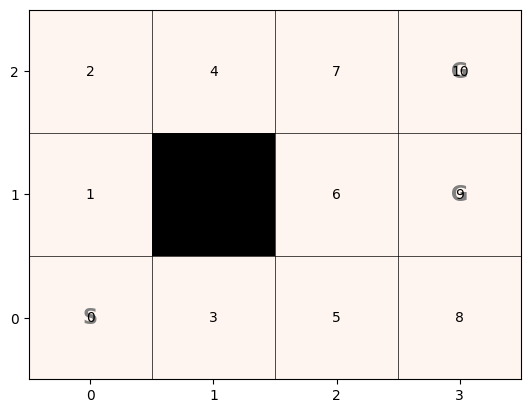

In [5]:
env.image()

## Define Linear State Features

In [6]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa_0, state_features, q_hat

In [7]:
# overwrite state_features for the semi-gradient Sarsa implementation in gym_classics
def state_features(s, env):
    return np.concatenate([np.array([1]), np.array(s)])

print(state_features((0,0), env))

gym_classics.algorithms.linear_approximation.state_features = state_features

[1 0 0]


In [9]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

# helper to visualize the learned policy and value function 
def plot_solution(w, title=None):
    Q = np.array([[q_hat(env.id2state(s), a, w, env) for a in env.actions()] for s in env.states()])
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title, clim=(-1,1))
    
    path_non_tabular = sample_episode(env, policy=pol, max_len=100)
    path = [(env.state2id(s), a, r, env.state2id(sp)) for s, a, r, sp in path_non_tabular]
    env.image(V, policy=pol, episode=path, title='Found Path', clim=(-1,1))


Learn weights.

Semi-Gradient SARSA(0): 100%|██████████| 1000/1000 [00:01<00:00, 972.91it/s]


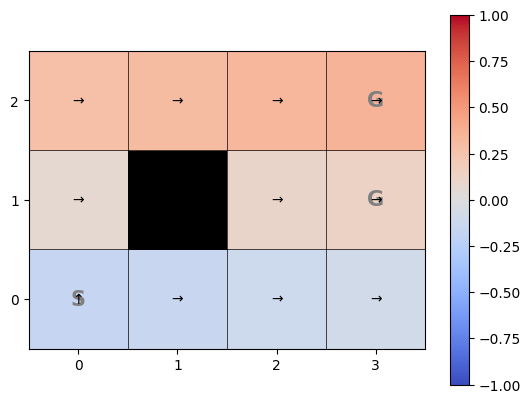

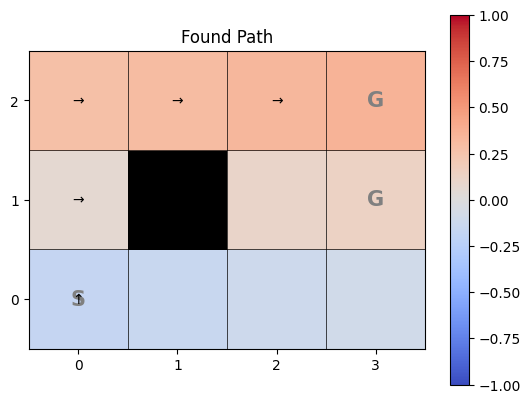

In [10]:
w = semi_gradient_Sarsa_0(env, n=1000, epsilon=0.1, alpha=0.001, gamma=.9, max_episode_length=1000, verbose=False)
plot_solution(w)

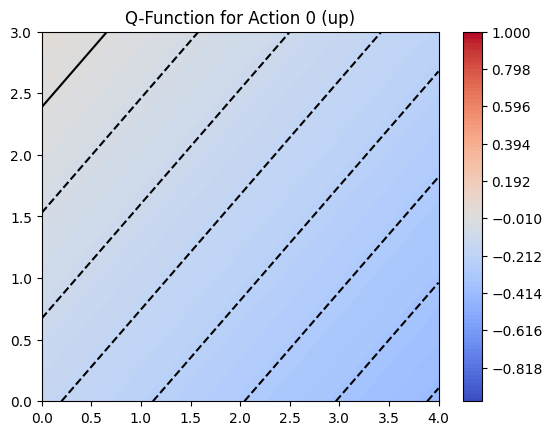

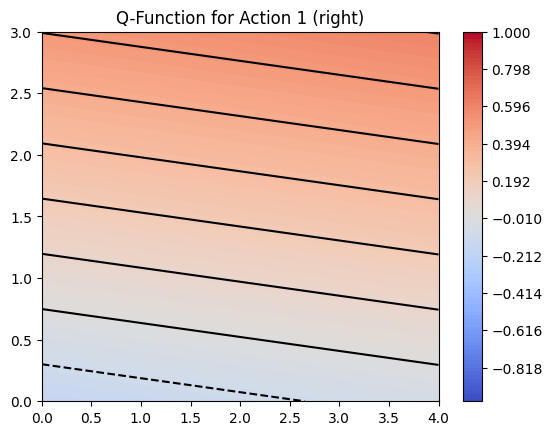

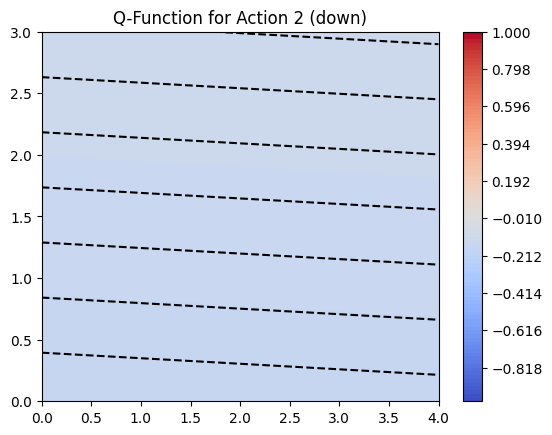

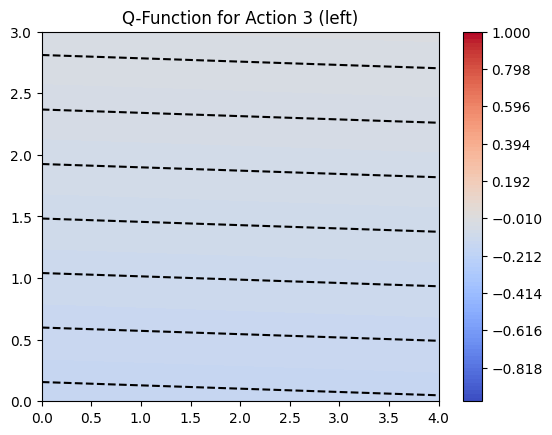

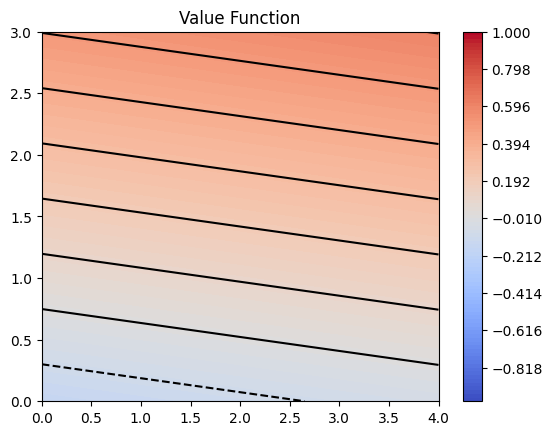

In [12]:
from matplotlib import pyplot as plt

dim = env.dims

def active_weights(a):
    return [0] + list(range(a*2+1, a*2+2+1))

def q_hat_grid(x, y, a, w):
    return np.dot(w[active_weights(a)], [1, x, y])

x = np.linspace(0, dim[0], 100)
y = np.linspace(0, dim[1], 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(env.action_space.n):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
    plt.contourf(X, Y, Z, cmap='coolwarm', levels=np.linspace(-1, 1, 100))
    plt.colorbar()
    plt.title(f'Q-Function for Action {a} ({env.id2action(a)})')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='coolwarm', levels=np.linspace(-1, 1, 100))
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()


It is very unlikely that linear approximation works well for this problem! The agent will get stuck or end up in the -1 square! We need to represent the states differently.


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)